In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
h = 1.0
m = 1.0

In [3]:
def SplitOperatorStep(psi, V, dt, k_vals):
    psi_k = np.fft.fft(psi)
    E_kin = (h**2 * k_vals**2) / (2.0 * m)
    psi_k *= np.exp(-0.5j * E_kin * dt / h)
    psi = np.fft.ifft(psi_k)

    psi *= np.exp(-1j * V * dt / h)

    psi_k = np.fft.fft(psi)
    psi_k *= np.exp(-0.5j * E_kin * dt / h)
    psi = np.fft.ifft(psi_k)
    return psi

In [4]:
Nx      = 512
x_min   = -40.0
x_max   =  40.0
L       = x_max - x_min
dx      = L / Nx

dt      = 0.025
n_steps = 500

In [5]:
x = np.linspace(x_min, x_max, Nx, endpoint=False)
dk = 2.0 * np.pi / L
k_vals = np.fft.fftfreq(Nx, d=dx) * 2.0 * np.pi

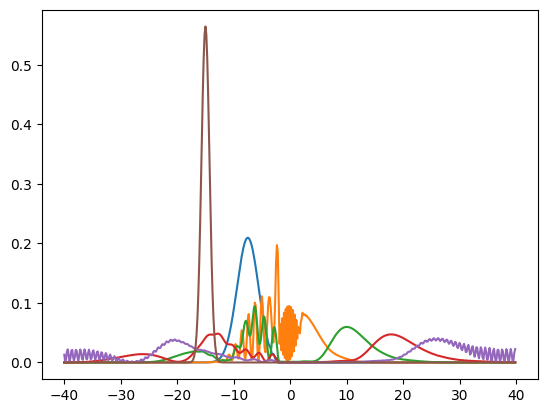

In [14]:
def finite_square_well(x, left_edge, right_edge, V0):
    V = np.zeros_like(x)
    mask = (x >= left_edge) & (x <= right_edge)
    V[mask] = -V0
    return V

V0         = 50.0 
well_left  = -2.0
well_right =  2.0
V = finite_square_well(x, well_left, well_right, V0)


x0    = -15.0 
sigma = 1.0
k0    = 3.0

def initial_gaussian_packet(x, x0, sigma, k0):
    norm_factor = 1.0 / (np.sqrt(sigma * np.sqrt(np.pi)))
    return norm_factor * np.exp(-0.5 * ((x - x0)/sigma)**2) * np.exp(1j * k0 * x)

psi0 = initial_gaussian_packet(x, x0, sigma, k0)
psi = initial_gaussian_packet(x, x0, sigma, k0)

for step in range(1, n_steps + 1):
    psi = SplitOperatorStep(psi, V, dt, k_vals)
    if step % 100 == 0:
        plt.plot(x, np.abs(psi)**2)
plt.plot(x, np.abs(psi0)**2)
plt.show()   